In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


files = {
    'Ethiopia': '../Data/ethiopia.csv',
    'Kenya': '../Data/kenya.csv',
    'Nigeria': '../Data/nigeria.csv',
    'Sudan': '../Data/sudan.csv',
    'Tanzania': '../Data/tanzania.csv'
}


# Load and merge
df_list = []
for country, path in files.items():
    temp_df = pd.read_csv(path)
    # Ensure Date conversion (assuming Task 2 logic was applied)
    temp_df['Date'] = pd.to_datetime(temp_df['YEAR'] * 1000 + temp_df['DOY'], format='%Y%j')
    temp_df['Country'] = country
    temp_df['Year'] = temp_df['Date'].dt.year
    df_list.append(temp_df)

all_data = pd.concat(df_list, ignore_index=True)
print(f"Successfully merged {len(all_data)} rows.")


Successfully merged 20540 rows.


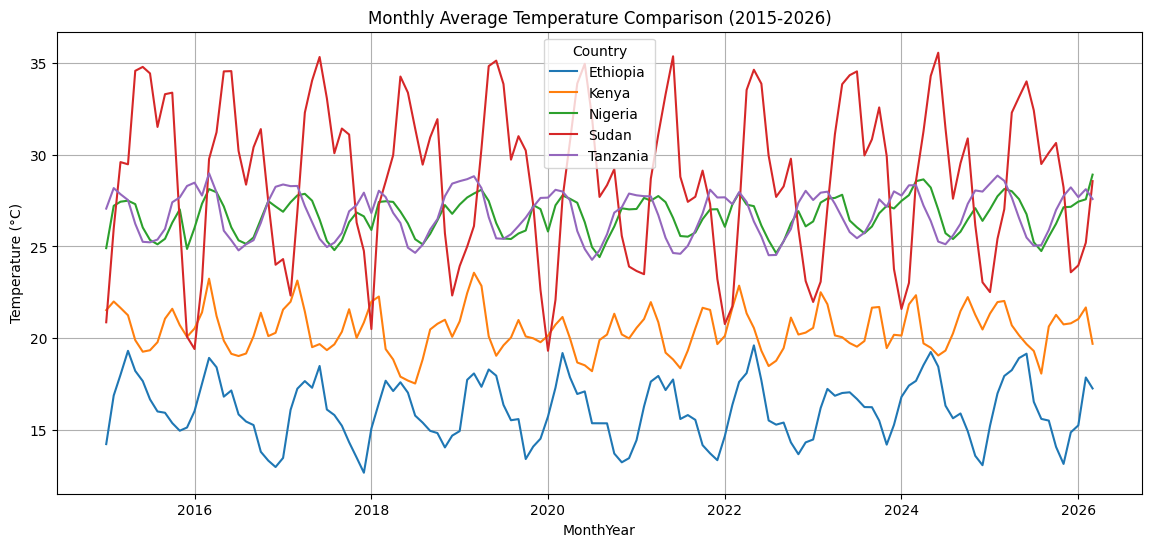

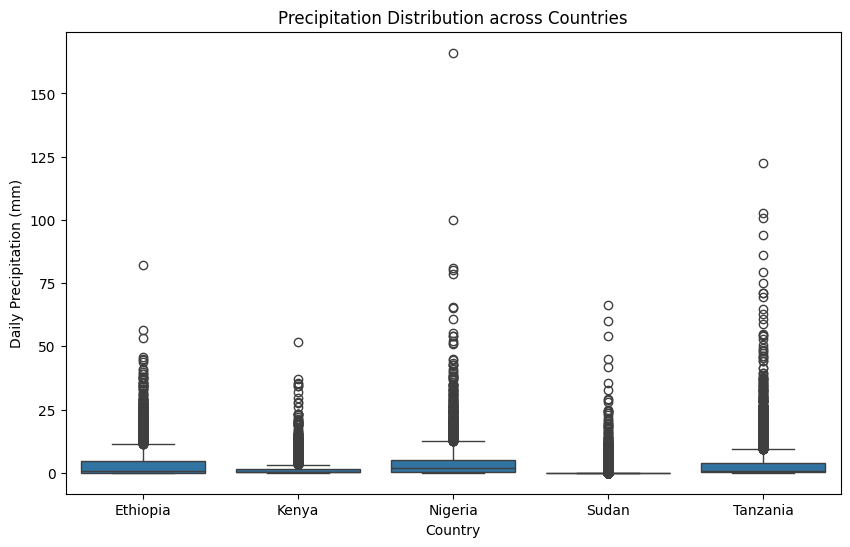

In [3]:
# Monthly Temperature Trend
all_data['MonthYear'] = all_data['Date'].dt.to_period('M').dt.to_timestamp()
monthly_avg = all_data.groupby(['Country', 'MonthYear'])['T2M'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg, x='MonthYear', y='T2M', hue='Country')
plt.title('Monthly Average Temperature Comparison (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

# Precipitation Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=all_data, x='Country', y='PRECTOTCORR')
plt.title('Precipitation Distribution across Countries')
plt.ylabel('Daily Precipitation (mm)')
plt.show()


In [4]:
# 1. Extreme Heat Days (>35°C)
extreme_heat = all_data[all_data['T2M_MAX'] > 35].groupby(['Country', 'Year']).size().reset_index(name='Heat_Days')

# 2. ANOVA Statistical Test
groups = [all_data[all_data['Country'] == c]['T2M'] for c in files.keys()]
f_stat, p_val = stats.f_oneway(*groups)

print(f"Extreme Heat Summary:\n", extreme_heat.groupby('Country')['Heat_Days'].mean())
print(f"\nANOVA P-Value: {p_val}")


Extreme Heat Summary:
 Country
Sudan    224.5
Name: Heat_Days, dtype: float64

ANOVA P-Value: 0.0
